# Train model for wind generation

* load wind data from database
* train test split
* train and evaluate base models 
    - LightGBM
    - XGBoost

In [1]:
# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")
util_dir = os.path.join(project_root, "util")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
if util_dir not in sys.path:
    sys.path.insert(0, util_dir)


import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2
    
from src.config import *
from util.weather_weighted import *
from src.etl_price import *
from src.fetch_price_data import *
from src.train_predict_model import *
from util.time_features import *

In [2]:
df = load_time_series_data_from_db()

print(df.info())
display(df.describe())
display(df.head())


<class 'pandas.DataFrame'>
DatetimeIndex: 65135 entries, 2018-12-31 23:00:00+00:00 to 2026-06-06 21:00:00+00:00
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   forecast_pv_mwh                   65111 non-null  float64
 1   forecast_wind_offshore_mwh        65111 non-null  float64
 2   forecast_wind_onshore_mwh         65111 non-null  float64
 3   gen_other_conventional_mwh        65103 non-null  float64
 4   gen_pv_mwh                        65103 non-null  float64
 5   gen_wind_offshore_mwh             65103 non-null  float64
 6   gen_wind_onshore_mwh              65103 non-null  float64
 7   price_de_lu_eur_mwh               65135 non-null  float64
 8   pv_weather_cloud_cover            65087 non-null  float64
 9   pv_weather_diffuse_radiation      65087 non-null  float64
 10  pv_weather_direct_radiation       65087 non-null  float64
 11  pv_weather_shortwave_radiation 

series_id,forecast_pv_mwh,forecast_wind_offshore_mwh,forecast_wind_onshore_mwh,gen_other_conventional_mwh,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh,pv_weather_cloud_cover,pv_weather_diffuse_radiation,pv_weather_direct_radiation,pv_weather_shortwave_radiation,wind_weather_wind_direction_100m,wind_weather_wind_speed_100m
count,65111.000000,65111.000000,65111.000000,65103.000000,65103.000000,65103.000000,65103.000000,65135.000000,65087.000000,65087.000000,65087.000000,65087.000000,65087.000000,65087.000000
mean,6390.164144,2887.569785,11905.687083,1593.921849,6384.566974,2900.217399,11975.892806,94.865921,65.938974,54.080498,81.468553,135.549051,204.522977,30.952394
std,9946.500745,1890.334257,9382.370101,266.829996,10015.511195,1968.172163,9467.646466,92.029588,27.861233,71.985345,140.780603,200.237761,75.733948,12.990564
min,0.000000,13.000000,161.250000,530.750000,0.000000,0.000000,46.500000,-500.000000,0.000000,0.000000,0.000000,0.000000,8.285717,3.491786
25%,0.000000,1134.500000,4579.000000,1415.250000,3.000000,1109.500000,4528.375000,38.250000,46.386554,0.000000,0.000000,0.000000,145.145419,21.262297
50%,241.750000,2720.750000,9164.250000,1577.250000,192.500000,2686.250000,9268.000000,76.980000,71.743608,5.724783,0.957522,7.245664,218.179864,29.192458
75%,10062.280000,4574.750000,16909.625000,1788.940000,9962.250000,4586.375000,17188.250000,116.520000,90.209652,98.161638,107.400408,221.161623,263.289240,38.652370
max,56410.320000,7344.190000,46758.440000,2669.500000,56071.650000,8448.340000,48499.500000,936.280000,100.000000,370.848847,766.031637,886.747525,355.010877,104.787703


series_id,forecast_pv_mwh,forecast_wind_offshore_mwh,forecast_wind_onshore_mwh,gen_other_conventional_mwh,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh,pv_weather_cloud_cover,pv_weather_diffuse_radiation,pv_weather_direct_radiation,pv_weather_shortwave_radiation,wind_weather_wind_direction_100m,wind_weather_wind_speed_100m
time,,,,,,,,,,,,,,
2018-12-31 23:00:00+00:00,0.0,5069.00,18879.75,1724.25,0.0,3134.00,20314.25,28.32,95.228754,0.0,0.0,0.0,257.697773,53.486212
2019-01-01 00:00:00+00:00,0.0,5042.25,20626.50,1682.25,0.0,2868.25,22297.25,10.07,93.784571,0.0,0.0,0.0,255.540277,58.021481
2019-01-01 01:00:00+00:00,0.0,5028.50,22355.50,1625.25,0.0,2460.25,23168.50,-4.08,99.448610,0.0,0.0,0.0,259.660683,59.465160
2019-01-01 02:00:00+00:00,0.0,4977.75,24032.50,1615.25,0.0,2696.50,24471.75,-9.91,100.000000,0.0,0.0,0.0,264.739757,60.351696
2019-01-01 03:00:00+00:00,0.0,4907.25,25452.00,1621.50,0.0,2578.00,26320.50,-7.41,98.505048,0.0,0.0,0.0,269.234658,61.293313


## Train model for wind generation

* prepare data
    - add time features: year, hour, month
    - add lag and rolling windows
    - create wind_speed_100m features
    - aggreate wind offshore and onshore
* train test split
* train and evaluate base model
    - LightGBM
    - XGBoost

In [3]:
# Keep time as a normal column for train_test_split_by_date
from util.time_features import TimeFeatureCreator
from src.config import DE_STATE_CODES, PANDEMIC_START, PANDEMIC_END
import pandas as pd 					

cols_wind_features = ['gen_wind_offshore_mwh', 
                      'gen_wind_onshore_mwh', 
                      #'wind_weather_wind_direction_100m', 
                      'wind_weather_wind_speed_100m']

df_wind = df[cols_wind_features].copy().reset_index()

# Physical thresholds for wind generation
# Cut-in: ~3m/s, Rated: ~13m/s, Cut-out: ~25m/s
v = df_wind['wind_weather_wind_speed_100m']
df_wind['wind_speed_clipped'] = v.clip(lower=3.0, upper=25.0)

# Power is proportional to v^3, but levels off at rated speed (~13m/s)
v_rated = v.clip(upper=13.0)
df_wind['wind_speed_pow2'] = v_rated ** 2
df_wind['wind_speed_pow3'] = v_rated ** 3

df_wind['gen_wind_total_mwh'] = df_wind['gen_wind_offshore_mwh'] + df_wind['gen_wind_onshore_mwh']
df_wind = df_wind.drop(['gen_wind_offshore_mwh', 'gen_wind_onshore_mwh'], axis=1)

# Create lag and rolling features
df_wind = create_lag_rolling_features(df_wind, 
                                      ['gen_wind_total_mwh', 'wind_weather_wind_speed_100m', 'wind_speed_pow2', 'wind_speed_pow3', 'wind_speed_clipped'] , 
                                      lags=(24, 168), 
                                      rolling_windows=(24, 168))

# Create time features
tfc = TimeFeatureCreator(
    country="DE",
    state_codes=DE_STATE_CODES,
    pandemic_start=PANDEMIC_START,
    pandemic_end=PANDEMIC_END,
    time_column="time",
    include_features=["year", "month", "hour"]
)

df_wind = tfc.create(df_wind, year=int(df_wind["time"].dt.year.max()))
df_wind = df_wind.dropna().reset_index(drop=True)

# train test split
train_end_date = pd.Timestamp("2025-10-01", tz="UTC")
wind_features_train, wind_target_train, wind_features_test, wind_target_test = train_test_split_by_date(
    df_wind, 'time', 'gen_wind_total_mwh', train_end_date
)

print(wind_features_train.shape)
print(wind_target_train.shape)
print(wind_features_test.shape)
print(wind_target_test.shape)
print(wind_features_train.columns)

(58993, 27)
(58993,)
(5926, 27)
(5926,)
Index(['wind_weather_wind_speed_100m', 'wind_speed_clipped', 'wind_speed_pow2',
       'wind_speed_pow3', 'gen_wind_total_mwh_lag_24h',
       'gen_wind_total_mwh_lag_168h', 'gen_wind_total_mwh_rolling_mean_24h',
       'gen_wind_total_mwh_rolling_mean_168h',
       'wind_weather_wind_speed_100m_lag_24h',
       'wind_weather_wind_speed_100m_lag_168h',
       'wind_weather_wind_speed_100m_rolling_mean_24h',
       'wind_weather_wind_speed_100m_rolling_mean_168h',
       'wind_speed_pow2_lag_24h', 'wind_speed_pow2_lag_168h',
       'wind_speed_pow2_rolling_mean_24h', 'wind_speed_pow2_rolling_mean_168h',
       'wind_speed_pow3_lag_24h', 'wind_speed_pow3_lag_168h',
       'wind_speed_pow3_rolling_mean_24h', 'wind_speed_pow3_rolling_mean_168h',
       'wind_speed_clipped_lag_24h', 'wind_speed_clipped_lag_168h',
       'wind_speed_clipped_rolling_mean_24h',
       'wind_speed_clipped_rolling_mean_168h', 'year', 'hour', 'month'],
      dtype='str', na

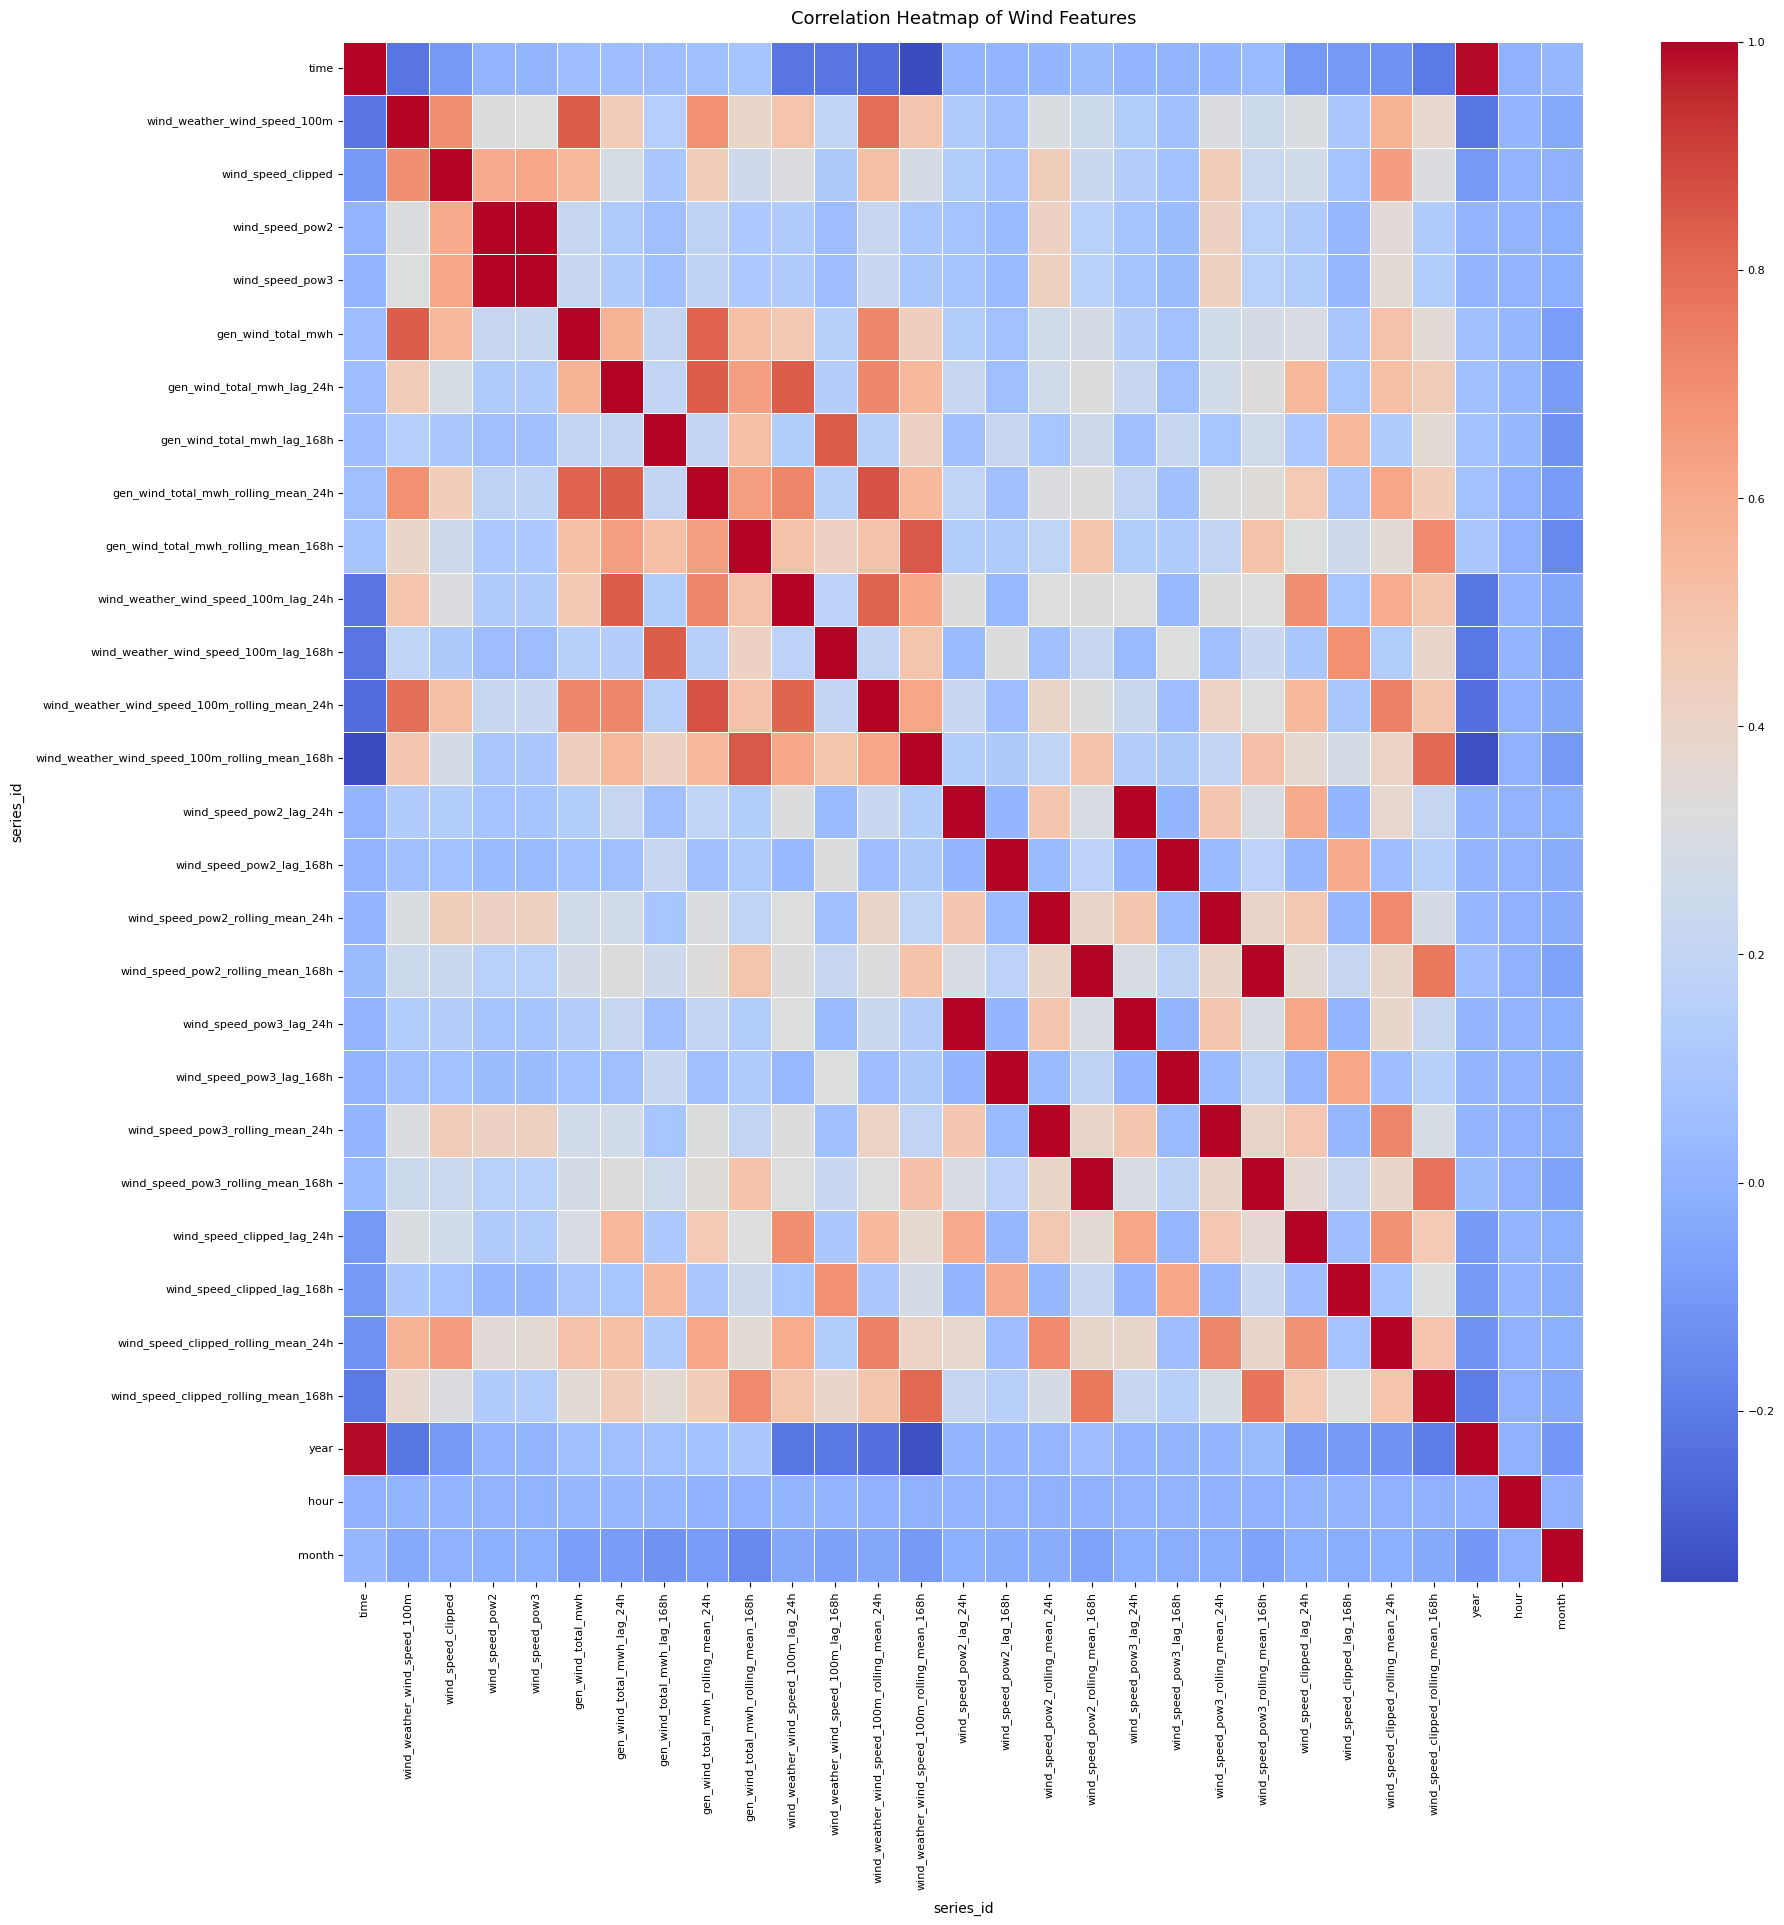

In [4]:
# plot correlation heatmap of the features
import seaborn as sns
plt.figure(figsize=(20, 20))
sns.heatmap(df_wind.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Wind Features")
plt.show()

In [5]:
# tune the best LightGBM model using Optuna
from lightgbm import LGBMRegressor

param_lgbm_continuous = { 
    'n_estimators': (50, 500),  # range for n_estimators
    'learning_rate': (0.01, 0.3),  # range for learning_rate
    'max_depth': (3, 15)  # range for max_depth
}

wind_model_lgbm =LGBMRegressor(random_state=42, force_col_wise=True)

# starting time
start_time = pd.Timestamp.now()
wind_best_model_lgbm, wind_best_params_lgbm = tune_model_bayesian(
    model_pipeline=wind_model_lgbm, 
    in_param_bayes=param_lgbm_continuous,
    in_features_train=wind_features_train, 
    in_target_train=wind_target_train)
print(f"Best hyperparameters: {wind_best_params_lgbm}")

print()

prediction_lgbm_wind = wind_best_model_lgbm.predict(wind_features_test)

print_scores('LightGBM', wind_target_test, prediction_lgbm_wind)  

save_model_to_pickle(wind_best_model_lgbm, '../models/wind_lgbm_model.pkl')

# training time
end_time = pd.Timestamp.now()
training_time = end_time - start_time
# show in minutes and seconds
minutes, seconds = divmod(training_time.total_seconds(), 60)
print(f"\nTraining time: {int(minutes)}'{int(seconds)}\"")

[LightGBM] [Info] Total Bins 6165
[LightGBM] [Info] Number of data points in the train set: 58993, number of used features: 27
[LightGBM] [Info] Start training from score 14549.760665
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [6]:
# tune the best XGBoost model using Optuna
from xgboost import XGBRegressor

param_xgb_continuous = {
    'n_estimators': (50, 500),  # range for n_estimators
    'max_depth': (3, 15),       # range for max_depth
    'learning_rate': (0.01, 0.3), # range for learning_rate
    'subsample': (0.5, 1.0),    # range for subsample
    'colsample_bytree': (0.5, 1.0), # range for colsample_bytree
    # max_features is categorical
    'max_features': [1.0, 'sqrt', 'log2'],
}

wind_model_xgb = XGBRegressor(random_state=42)
start_time = pd.Timestamp.now()
wind_best_model_xgb, wind_best_params_xgb = tune_model_bayesian(
    model_pipeline=wind_model_xgb,
    in_param_bayes=param_xgb_continuous,
    in_features_train=wind_features_train,   
    in_target_train=wind_target_train
)
print(f"Best hyperparameters for XGBoost: {wind_best_params_xgb}")

y_pred_xgb = wind_best_model_xgb.predict(wind_features_test)

print_scores('XGBoost', wind_target_test, y_pred_xgb)

save_model_to_pickle(wind_best_model_xgb, '../models/wind_xgb_model.pkl')

# training time
end_time = pd.Timestamp.now()
training_time = end_time - start_time
# show in minutes and seconds
minutes, seconds = divmod(training_time.total_seconds(), 60)
print(f"\nTraining time: {int(minutes)}'{int(seconds)}\"")

Best hyperparameters for XGBoost: OrderedDict({'colsample_bytree': 1.0, 'learning_rate': 0.06232888552703363, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 497, 'subsample': 0.5818118673307682})
-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost             2633.19    3513.63     0.91

Training time: 6'36"


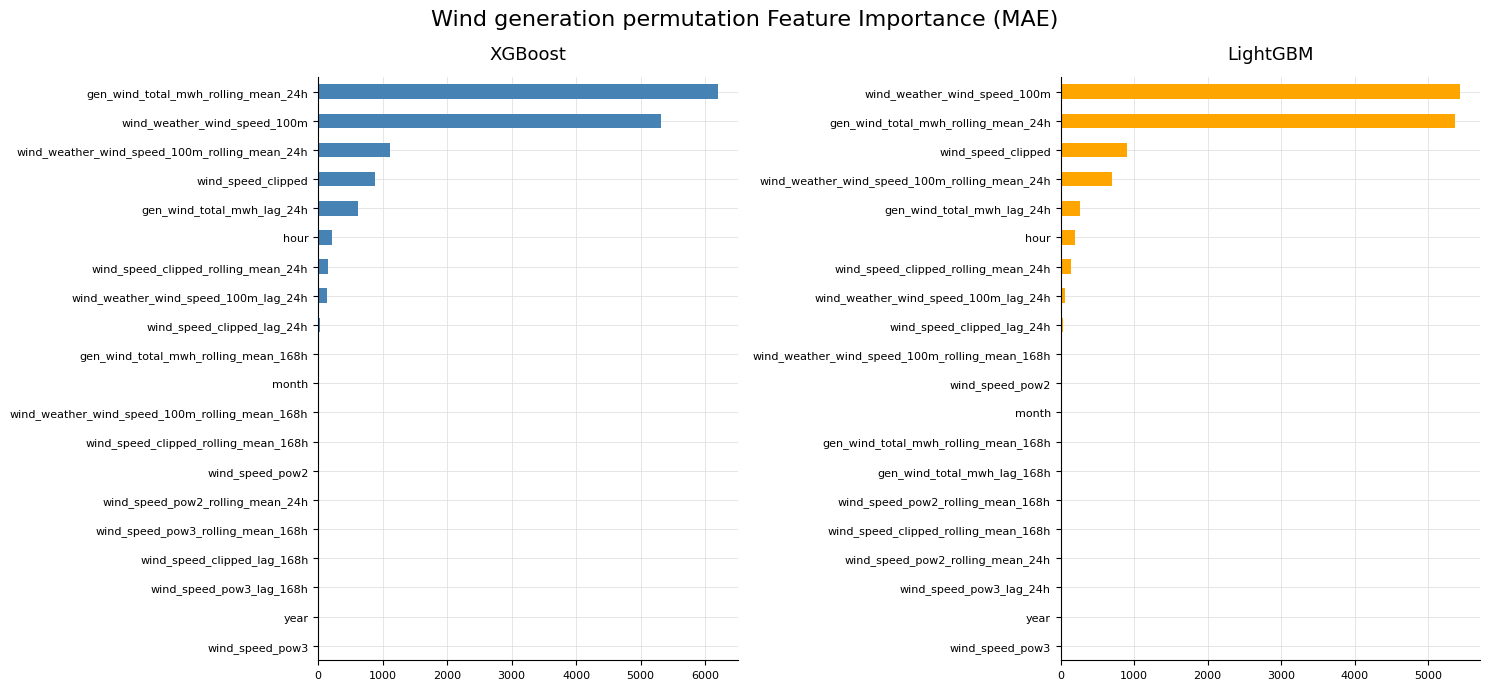

In [7]:
# plot permutation feature importance of three selected models of top 20 features for MAE
from sklearn.inspection import permutation_importance

perm_importance_mae_lgbm = permutation_importance(wind_best_model_lgbm, wind_features_test, wind_target_test, scoring='neg_mean_absolute_error')
perm_importance_mae_xgb = permutation_importance(wind_best_model_xgb, wind_features_test, wind_target_test, scoring='neg_mean_absolute_error')
perm_importances_mae_lgbm = pd.Series(perm_importance_mae_lgbm.importances_mean, index=wind_best_model_lgbm.feature_names_in_).sort_values(ascending=True).tail(20)
perm_importances_mae_xgb = pd.Series(perm_importance_mae_xgb.importances_mean, index=wind_best_model_xgb.feature_names_in_).sort_values(ascending=True).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
perm_importances_mae_lgbm.plot.barh(ax=axes[1], color='orange')
axes[1].set_title("LightGBM")
perm_importances_mae_xgb.plot.barh(ax=axes[0], color='steelblue') 
axes[0].set_title("XGBoost")
fig.suptitle("Wind generation permutation Feature Importance (MAE)", fontsize=16)
plt.tight_layout()
plt.show()


# Try separate wind onshore and offshore predictions

* get locations and capacities for wind onshore and offshore
* aggregate the wind data
* train and evaluate models

In [4]:
# ------------- Test the weather weighting process on a short date range -----------------

# Keep this range short for fast iteration during development.
START_DATE = "2026-01-01"
END_DATE = "2026-05-30"

WIND_LAND_CAPACITY_CSV = Path("../data/processed/wind_land_cluster_yearly_capacity_since_2019.csv")
WIND_SEA_CAPACITY_CSV = Path("../data/processed/wind_sea_cluster_yearly_capacity_since_2019.csv")

WIND_LAND_OUTPUT_CSV = Path("../data/processed/wind_land_weather_weighted_hourly.csv")
WIND_SEA_OUTPUT_CSV = Path("../data/processed/wind_sea_weather_weighted_hourly.csv")

wind_land_weights_by_year = build_yearly_weights(WIND_LAND_CAPACITY_CSV, technology_prefix="wind_land")
wind_sea_weights_by_year = build_yearly_weights(WIND_SEA_CAPACITY_CSV, technology_prefix="wind_sea")

print('Wind Land cluster locations:\n', WIND_CLUSTER_LOCATIONS_LAND)
print("Wind Land weights by year:\n", wind_land_weights_by_year)

print('Wind Sea cluster locations:\n', WIND_CLUSTER_LOCATIONS_SEA)
print("Wind Sea weights by year:\n", wind_sea_weights_by_year)

df_weather_wind_land = fetch_weighted_weather_for_technology(
    technology_name="wind_land",
    locations=WIND_CLUSTER_LOCATIONS_LAND,
    weather_variables=WIND_WEATHER_VARIABLES,
    weights_by_year=wind_land_weights_by_year,
    start_date=START_DATE,
    end_date=END_DATE,
    selected_cities=SELECTED_CITIES,
    city_population=CITY_POPULATION,
    city_sleep=0.1,
 )

df_weather_wind_sea = fetch_weighted_weather_for_technology(
    technology_name="wind_sea",
    locations=WIND_CLUSTER_LOCATIONS_SEA,
    weather_variables=WIND_WEATHER_VARIABLES,
    weights_by_year=wind_sea_weights_by_year,
    start_date=START_DATE,
    end_date=END_DATE,
    selected_cities=SELECTED_CITIES,
    city_population=CITY_POPULATION,
    city_sleep=0.1,
 )

df_weather_wind_land.to_csv(WIND_LAND_OUTPUT_CSV, index=False)
df_weather_wind_sea.to_csv(WIND_SEA_OUTPUT_CSV, index=False)

print("Wind Land columns:", list(df_weather_wind_land.columns))
print("Wind Sea columns:", list(df_weather_wind_sea.columns))
display(df_weather_wind_land.head(3))
display(df_weather_wind_sea.head(3))

Wind Land cluster locations:
 {'wind_land_cluster_0': {'latitude': 54.14415, 'longitude': 9.865936}, 'wind_land_cluster_1': {'latitude': 52.253366, 'longitude': 7.417368}, 'wind_land_cluster_2': {'latitude': 52.544914, 'longitude': 13.9168}, 'wind_land_cluster_3': {'latitude': 48.735615, 'longitude': 10.063631}, 'wind_land_cluster_4': {'latitude': 53.076917, 'longitude': 8.966918}, 'wind_land_cluster_5': {'latitude': 52.24592, 'longitude': 10.581706}, 'wind_land_cluster_6': {'latitude': 49.664907, 'longitude': 7.580589}, 'wind_land_cluster_7': {'latitude': 51.03763, 'longitude': 6.355913}, 'wind_land_cluster_8': {'latitude': 52.488807, 'longitude': 12.155722}, 'wind_land_cluster_9': {'latitude': 51.414065, 'longitude': 8.853566}}
Wind Land weights by year:
 {2019: {'wind_land_cluster_0': 0.002949916795222847, 'wind_land_cluster_1': 0.16539381778387305, 'wind_land_cluster_2': 0.2853768187910478, 'wind_land_cluster_3': 0.0, 'wind_land_cluster_4': 0.017775389132164057, 'wind_land_cluster_

,time,wind_speed_100m,wind_direction_100m
0,2026-01-01 00:00:00+01:00,33.740015,253.610256
1,2026-01-01 01:00:00+01:00,34.051217,251.865710
2,2026-01-01 02:00:00+01:00,35.556647,249.940338


,time,wind_speed_100m,wind_direction_100m
0,2026-01-01 00:00:00+01:00,46.800193,254.023055
1,2026-01-01 01:00:00+01:00,46.665034,257.595582
2,2026-01-01 02:00:00+01:00,49.726898,250.748320


In [5]:
# Keep time as a normal column for train_test_split_by_date
from util.time_features import TimeFeatureCreator
from src.config import DE_STATE_CODES, PANDEMIC_START, PANDEMIC_END
import pandas as pd 					

def engineer_wind_features(df, gen_col, weather_col):
    cols_wind_features = [gen_col, weather_col]

    df_wind = df[cols_wind_features].copy().reset_index()
    # Physical thresholds for wind generation
    # Cut-in: ~3m/s, Rated: ~13m/s, Cut-out: ~25m/s
    v = df_wind[weather_col]
    df_wind['wind_speed_clipped'] = v.clip(lower=3.0, upper=25.0)

    # Power is proportional to v^3, but levels off at rated speed (~13m/s)
    v_rated = v.clip(upper=13.0)
    df_wind['wind_speed_pow2'] = v_rated ** 2
    df_wind['wind_speed_pow3'] = v_rated ** 3

    # Create time features
    tfc = TimeFeatureCreator(
        country="DE",
        state_codes=DE_STATE_CODES,
        pandemic_start=PANDEMIC_START,
        pandemic_end=PANDEMIC_END,
        time_column="time",
        include_features=["year", "month", "hour"]
    )

    df_wind = tfc.create(df_wind, year=int(df_wind["time"].dt.year.max()))

    # Create lag and rolling features
    df_wind = create_lag_rolling_features(df_wind, 
                                        [gen_col, weather_col, 'wind_speed_pow2', 'wind_speed_pow3', 'wind_speed_clipped'] , 
                                        lags=(24, 168), 
                                        rolling_windows=(24, 168))
    df_wind = df_wind.dropna().reset_index(drop=True)
    
    return df_wind

df = load_time_series_data_from_db()
df_wind_land = engineer_wind_features(df, 'gen_wind_onshore_mwh', 'wind_weather_wind_speed_100m')
df_wind_sea = engineer_wind_features(df, 'gen_wind_offshore_mwh', 'wind_weather_wind_speed_100m')

# train test split
train_end_date = pd.Timestamp("2025-10-01", tz="UTC")
wind_land_features_train, wind_land_target_train, wind_land_features_test, wind_land_target_test = train_test_split_by_date(
    df_wind_land, 'time', 'gen_wind_onshore_mwh', train_end_date
)
wind_sea_features_train, wind_sea_target_train, wind_sea_features_test, wind_sea_target_test = train_test_split_by_date(
    df_wind_sea, 'time', 'gen_wind_offshore_mwh', train_end_date
)


print(wind_land_features_train.shape)
print(wind_land_target_train.shape)
print(wind_land_features_test.shape)
print(wind_land_target_test.shape)

print(wind_sea_features_train.shape)
print(wind_sea_target_train.shape)
print(wind_sea_features_test.shape)
print(wind_sea_target_test.shape)

(58993, 27)
(58993,)
(5854, 27)
(5854,)
(58993, 27)
(58993,)
(5854, 27)
(5854,)


In [6]:
# tune the best LightGBM model using Optuna
from lightgbm import LGBMRegressor

param_lgbm_continuous = { 
    'n_estimators': (50, 500),  # range for n_estimators
    'learning_rate': (0.01, 0.3),  # range for learning_rate
    'max_depth': (3, 15)  # range for max_depth
}

wind_model_lgbm =LGBMRegressor(random_state=42, force_col_wise=True)

# starting time
start_time = pd.Timestamp.now()
wind_land_best_model_lgbm, wind_land_best_params_lgbm = tune_model_bayesian(
    model_pipeline=wind_model_lgbm, 
    in_param_bayes=param_lgbm_continuous,
    in_features_train=wind_land_features_train, 
    in_target_train=wind_land_target_train)
print(f"Best hyperparameters: {wind_land_best_params_lgbm}")

print()

prediction_lgbm_wind = wind_land_best_model_lgbm.predict(wind_land_features_test)

print_scores('LightGBM', wind_land_target_test, prediction_lgbm_wind)  

save_model_to_pickle(wind_land_best_model_lgbm, '../models/wind_land_lgbm_model.pkl')


[LightGBM] [Info] Total Bins 6165
[LightGBM] [Info] Number of data points in the train set: 58993, number of used features: 27
[LightGBM] [Info] Start training from score 11738.253282
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [7]:
# tune the best LightGBM model using Optuna
from lightgbm import LGBMRegressor

param_lgbm_continuous = { 
    'n_estimators': (50, 500),  # range for n_estimators
    'learning_rate': (0.01, 0.3),  # range for learning_rate
    'max_depth': (3, 15)  # range for max_depth
}

wind_sea_model_lgbm =LGBMRegressor(random_state=42, force_col_wise=True)

# starting time
start_time = pd.Timestamp.now()
wind_sea_best_model_lgbm, wind_sea_best_params_lgbm = tune_model_bayesian(
    model_pipeline=wind_sea_model_lgbm, 
    in_param_bayes=param_lgbm_continuous,
    in_features_train=wind_sea_features_train, 
    in_target_train=wind_sea_target_train)
print(f"Best hyperparameters: {wind_sea_best_params_lgbm}")

print()

prediction_lgbm_wind = wind_sea_best_model_lgbm.predict(wind_sea_features_test)

print_scores('LightGBM', wind_sea_target_test, prediction_lgbm_wind)  

save_model_to_pickle(wind_sea_best_model_lgbm, '../models/wind_sea_lgbm_model.pkl')


[LightGBM] [Info] Total Bins 6165
[LightGBM] [Info] Number of data points in the train set: 58993, number of used features: 27
[LightGBM] [Info] Start training from score 2811.507384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

## Conclusion

* Wind onshore and offshore predictions reach worse R² than aggregated
* stay at the aggregated wind generation

| Wind       | MAE      | RMSE      | R²   |
|---|---|---|---|
| aggregated | 2647.24  | 3534.82   | 0.91 |
| Onshore    | 2683.88  | 3510.06   | 0.88 |
| Offshore   | 764.61   | 993.20    | 0.82 |